# Инициализация

Загружаем библиотеки необходимые для выполнения кода ноутбука.

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = '../'

logger = logging.getLogger('recsys')
logger.setLevel(0)

%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

In [2]:
tracks = pd.read_parquet(ROOT + "data/tracks.parquet")
catalog_names = pd.read_parquet(ROOT + "data/catalog_names.parquet")
interactions = pd.read_parquet(ROOT + "data/interactions.parquet")

In [3]:
interactions.shape, tracks.shape, catalog_names.shape

((222629898, 4), (1000000, 4), (1812471, 3))

In [5]:
tracks_limit = interactions.groupby('track_id').agg(count=('user_id', 'count')).reset_index().query('count > 1000')

In [4]:
# track_seq_agg = interactions.groupby('user_id').agg(track_seq_max=('track_seq', 'max')).reset_index()
# interactions = interactions.merge(track_seq_agg, on='user_id', how='left')
# interactions['track_seq_inverse'] = interactions['track_seq_max'] - interactions['track_seq'] + 1

In [5]:
# interactions = interactions.query('track_seq_max > 10')
# interactions = interactions.query('track_seq_inverse < 11')

In [6]:
tracks = tracks[tracks['track_id'].isin(tracks_limit['track_id'].unique())]
interactions = interactions[interactions['track_id'].isin(tracks_limit['track_id'].unique())]

In [7]:
interactions.shape, tracks.shape, catalog_names.shape

((154899045, 4), (39849, 4), (1812471, 3))

In [8]:
popularity = interactions.groupby(['track_id']).agg(count=('user_id', 'count')).reset_index()

popularity['rating'] =  pd.qcut(popularity['count'], q=100, labels=False, duplicates='drop').astype('int') + 1


<Axes: >

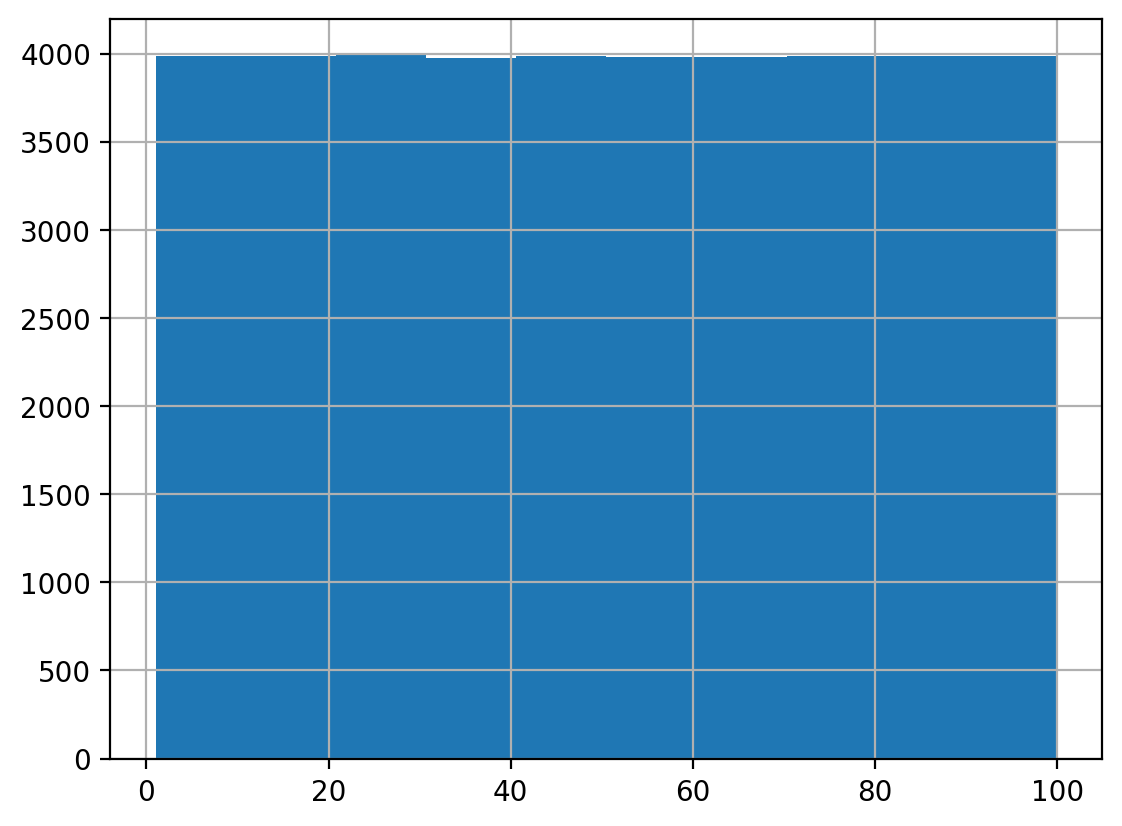

In [9]:
popularity['rating'].hist()

In [8]:
# tracks_genres = tracks.explode('genres', ignore_index=True)[['track_id', 'genres']]
# tracks_genres.rename(columns={'genres': 'genre'}, inplace=True)
# tracks_genres['genre'].fillna('unknown', inplace=True)


# popularity = popularity.merge(tracks_genres, on='track_id', how='left')

# genre_agg = popularity.groupby(['genre']).agg(genre_count_max=('count', 'max')).reset_index()
# popularity = popularity.merge(genre_agg, on='genre', how='left')

# popularity['rating'] = 0

# for _, row in genre_agg.iterrows():
#     genre = row['genre']
#     genre_idx = popularity['genre'] == genre
#     genre_popularity = popularity[genre_idx]
#     popularity.loc[genre_idx, 'rating'] = pd.qcut(popularity[genre_idx]['count'], q=10, labels=False, duplicates='drop').astype('int')

# popularity['rating'] = (popularity['rating'] + popularity['count'] / popularity['genre_count_max'])
# popularity = popularity.groupby(['track_id']).agg(rating=('rating', 'mean'), count=('count', 'max')).reset_index()

In [13]:
popularity.sample(8).T

,34985,26377,26528,25793,3908,10646,15797,38615
track_id,71950768,48884423,49218719,47020137,651455,19024303,29866443,88425332
count,3997,1371,2002,2100,1056,1321,3901,2758
rating,76,25,48,51,5,22,75,63


In [14]:
interactions = interactions.merge(popularity, on='track_id', how='left')

In [15]:
interactions["rank"] = interactions.groupby("user_id").cumcount(ascending=False) + 1


In [17]:
interactions = interactions.query('rank < 11')

In [18]:
interactions

,user_id,track_id,track_seq,started_at,count,rating,rank
0,0,99262,1,2022-07-17,2524,60,10
1,0,589498,2,2022-07-19,2392,57,9
2,0,597196,7,2022-07-25,23511,99,8
3,0,597199,8,2022-07-25,8421,91,7
4,0,10327926,15,2022-08-19,1440,28,6
...,...,...,...,...,...,...,...
154899040,1374582,94960284,284,2022-12-29,3863,75,5
154899041,1374582,97220301,289,2022-12-29,2950,66,4
154899042,1374582,97241171,290,2022-12-29,5701,85,3
154899043,1374582,98542641,291,2022-12-29,3293,70,2


# Сохранение данных

Сохраним данные в двух файлах в персональном S3-бакете по пути `recsys/data/`:
- `items.parquet` — все данные о музыкальных треках,
- `events.parquet` — все данные о взаимодействиях.

In [19]:
items = tracks
events = interactions

items = items.rename(columns={'track_id': 'item_id'})
events = events.rename(columns={'track_id': 'item_id'})

items.to_parquet(ROOT + "data/items.parquet")
events.to_parquet(ROOT + "data/events.parquet")

In [ ]:
raise ''

# Очистка памяти

Здесь, может понадобится очистка памяти для высвобождения ресурсов для выполнения кода ниже. 

Приведите соответствующие код, комментарии, например:
- код для удаление более ненужных переменных,
- комментарий, что следует перезапустить kernel, выполнить такие-то начальные секции и продолжить с этапа 3.

In [20]:
del tracks
del interactions

In [1]:
import logging

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

ROOT = '../'

logger = logging.getLogger('recsys')
logger.setLevel(0)

%matplotlib inline
%config InlineBackend.figure_format = 'png'
%config InlineBackend.figure_format = 'retina'

# === ЭТАП 3 ===

# Загрузка данных

Если необходимо, то загружаем items.parquet, events.parquet.

In [2]:
items = pd.read_parquet(ROOT + "data/items.parquet")
events = pd.read_parquet(ROOT + "data/events.parquet")

# Разбиение данных

Разбиваем данные на тренировочную, тестовую выборки.

In [4]:
train_split_date = pd.to_datetime('2022-11-01').to_datetime64()
train_split_date_idx = events['started_at'] < train_split_date

events_train = events[train_split_date_idx]
events_test = events[~train_split_date_idx]

# количество пользователей в train и test
users_train = events_train['user_id'].drop_duplicates()
users_test = events_test['user_id'].drop_duplicates()
# количество пользователей, которые есть и в train, и в test
common_users = set(users_train) & set(users_test)

print(len(users_train), len(users_test), len(common_users)) 

1188565 1185989 1001333


In [5]:
events_train.shape, events_test.shape

((157617360, 7), (65012538, 7))

# Топ популярных

Рассчитаем рекомендации как топ популярных.

# Персональные

Рассчитаем персональные рекомендации.

In [5]:
from surprise import Dataset, Reader
from surprise import SVD

# используем Reader из библиотеки surprise для преобразования событий (events)
# в формат, необходимый surprise
reader = Reader(rating_scale=(1, 5))
surprise_train_set = Dataset.load_from_df(events_train[['user_id', 'item_id', 'rating']], reader)
# surprise_train_set = surprise_train_set.build_full_trainset()

# # инициализируем модель
# svd_model = SVD(n_factors=100, random_state=0)

# # обучаем модель
# svd_model.fit(surprise_train_set) 

In [8]:
reader.

[0, 1, 2]

# Похожие

Рассчитаем похожие, они позже пригодятся для онлайн-рекомендаций.

# Построение признаков

Построим три признака, можно больше, для ранжирующей модели.

# Ранжирование рекомендаций

Построим ранжирующую модель, чтобы сделать рекомендации более точными. Отранжируем рекомендации.

# Оценка качества

Проверим оценку качества трёх типов рекомендаций: 

- топ популярных,
- персональных, полученных при помощи ALS,
- итоговых
  
по четырем метрикам: recall, precision, coverage, novelty.

# === Выводы, метрики ===

Основные выводы при работе над расчётом рекомендаций, рассчитанные метрики.